# U.S. Medical Insurance Costs

My first independent data analysis project, provided by Codecademy as part of their Data Scientist: Analytics Specialist Career Path. The purpose of this project is to identify correlations between how much people pay in medical insurance in the United States and six other factors.

In [36]:
# Import Dependencies
import csv
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

In [37]:
# Bring in and load insurance.csv
# Data is brought in as a list of dictionaries
with open('insurance.csv', newline='') as insurance_costs:
    insurance_data = list(csv.DictReader(insurance_costs))
    for row in insurance_data:
        print(row)

{'age': '19', 'sex': 'female', 'bmi': '27.9', 'children': '0', 'smoker': 'yes', 'region': 'southwest', 'charges': '16884.924'}
{'age': '18', 'sex': 'male', 'bmi': '33.77', 'children': '1', 'smoker': 'no', 'region': 'southeast', 'charges': '1725.5523'}
{'age': '28', 'sex': 'male', 'bmi': '33', 'children': '3', 'smoker': 'no', 'region': 'southeast', 'charges': '4449.462'}
{'age': '33', 'sex': 'male', 'bmi': '22.705', 'children': '0', 'smoker': 'no', 'region': 'northwest', 'charges': '21984.47061'}
{'age': '32', 'sex': 'male', 'bmi': '28.88', 'children': '0', 'smoker': 'no', 'region': 'northwest', 'charges': '3866.8552'}
{'age': '31', 'sex': 'female', 'bmi': '25.74', 'children': '0', 'smoker': 'no', 'region': 'southeast', 'charges': '3756.6216'}
{'age': '46', 'sex': 'female', 'bmi': '33.44', 'children': '1', 'smoker': 'no', 'region': 'southeast', 'charges': '8240.5896'}
{'age': '37', 'sex': 'female', 'bmi': '27.74', 'children': '3', 'smoker': 'no', 'region': 'northwest', 'charges': '7281.

In [38]:
# Data columns saved separately as lists using list comprehensions
age = [int(row['age']) for row in insurance_data]
sex = [row['sex'] for row in insurance_data]
bmi = [float(row['bmi']) for row in insurance_data]
children = [int(row['children']) for row in insurance_data]
smoker = [row['smoker'] for row in insurance_data]
region = [row['region'] for row in insurance_data]
charges = [round(float(row['charges']), 2) for row in insurance_data]




# Checking the distribution of the values in the data columns

In [39]:
# Use Counter from collections to count the number of times the various values occur in the columns
# Charges column not accounted for
age_counts = Counter(age)
sex_counts = Counter(sex)
bmi_counts = Counter(bmi)
children_counts = Counter(children)
smoker_counts = Counter(smoker)
region_counts = Counter(region)

print(age_counts)
print(sex_counts)
print(bmi_counts)
print(children_counts)
print(smoker_counts)
print(region_counts)

# All Counter objects saved to a list
column_variable_counts = [age_counts, sex_counts, bmi_counts, children_counts, smoker_counts, region_counts]

# Names describing columns, to be used for bar chart labels
column_variable_names = ["Ages", "Sexes", "BMI", "Children", "Smokers", "Regions"]


Counter({18: 69, 19: 68, 46: 29, 52: 29, 48: 29, 20: 29, 45: 29, 47: 29, 51: 29, 50: 29, 28: 28, 25: 28, 23: 28, 27: 28, 22: 28, 26: 28, 24: 28, 21: 28, 53: 28, 54: 28, 49: 28, 31: 27, 30: 27, 41: 27, 40: 27, 43: 27, 44: 27, 29: 27, 42: 27, 33: 26, 32: 26, 56: 26, 34: 26, 55: 26, 57: 26, 37: 25, 59: 25, 35: 25, 38: 25, 36: 25, 58: 25, 39: 25, 60: 23, 62: 23, 63: 23, 61: 23, 64: 22})
Counter({'male': 676, 'female': 662})
Counter({32.3: 13, 28.31: 9, 28.88: 8, 34.1: 8, 30.8: 8, 30.875: 8, 31.35: 8, 30.495: 8, 32.775: 7, 35.2: 7, 27.36: 7, 34.8: 7, 25.46: 7, 32.11: 7, 30.59: 7, 38.06: 7, 24.32: 7, 27.645: 7, 33.33: 7, 25.8: 7, 33.0: 6, 27.74: 6, 29.83: 6, 26.6: 6, 33.63: 6, 35.53: 6, 19.95: 6, 30.115: 6, 29.92: 6, 27.5: 6, 28.595: 6, 37.1: 6, 25.175: 6, 26.41: 6, 30.2: 6, 31.73: 6, 25.84: 5, 30.78: 5, 31.92: 5, 28.025: 5, 26.315: 5, 31.825: 5, 33.66: 5, 28.9: 5, 28.5: 5, 29.7: 5, 28.975: 5, 28.785: 5, 25.3: 5, 36.85: 5, 29.64: 5, 33.155: 5, 33.345: 5, 27.835: 5, 23.21: 5, 32.395: 5, 34.2:

In [40]:
# Counter objects are internally rearranged according to keys in ascending order
# First indented line is generated by Google AI
sorted_counts = []
for column in column_variable_counts:
    column = dict(sorted(column.items(), key = lambda item: item[0]))
    sorted_counts.append(column)

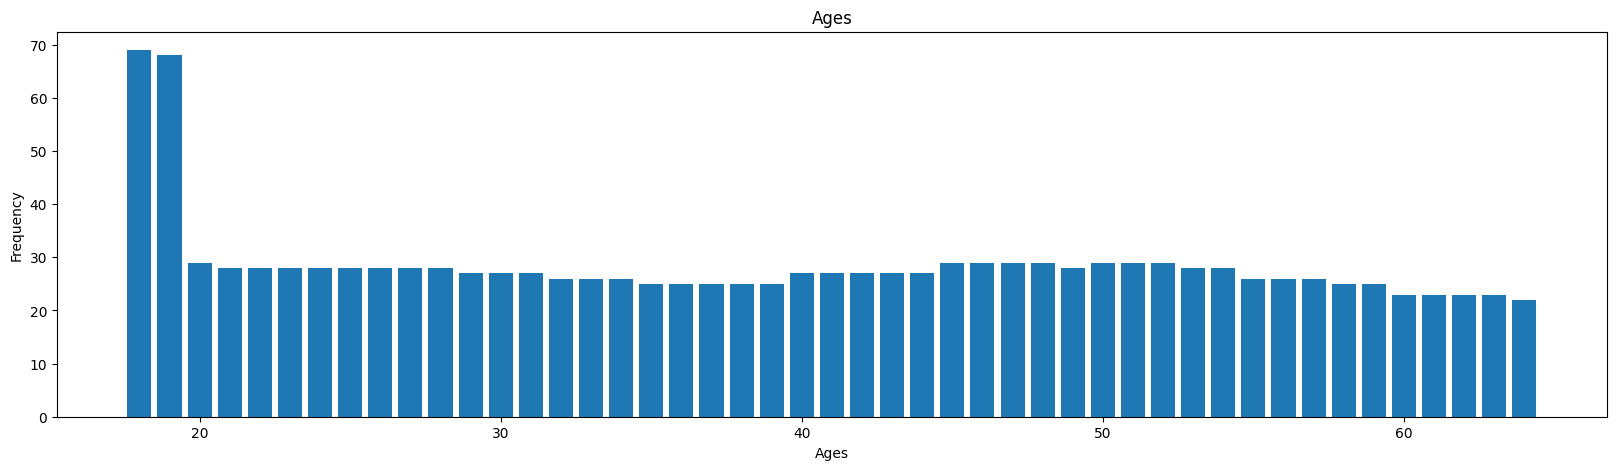

<Figure size 640x480 with 0 Axes>

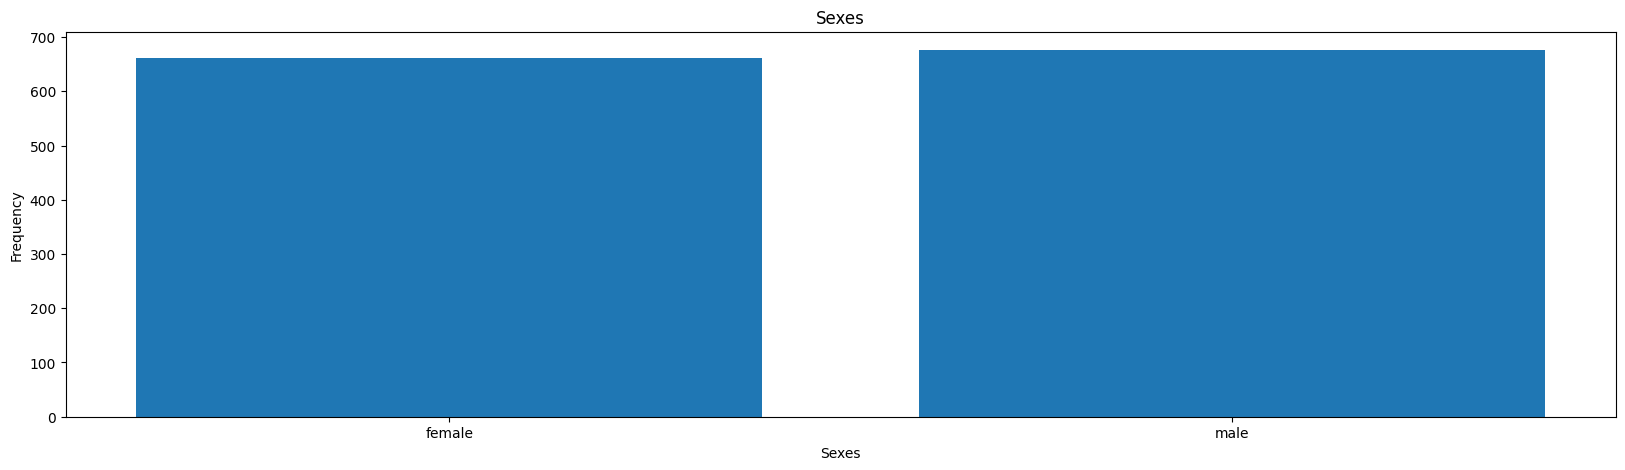

<Figure size 640x480 with 0 Axes>

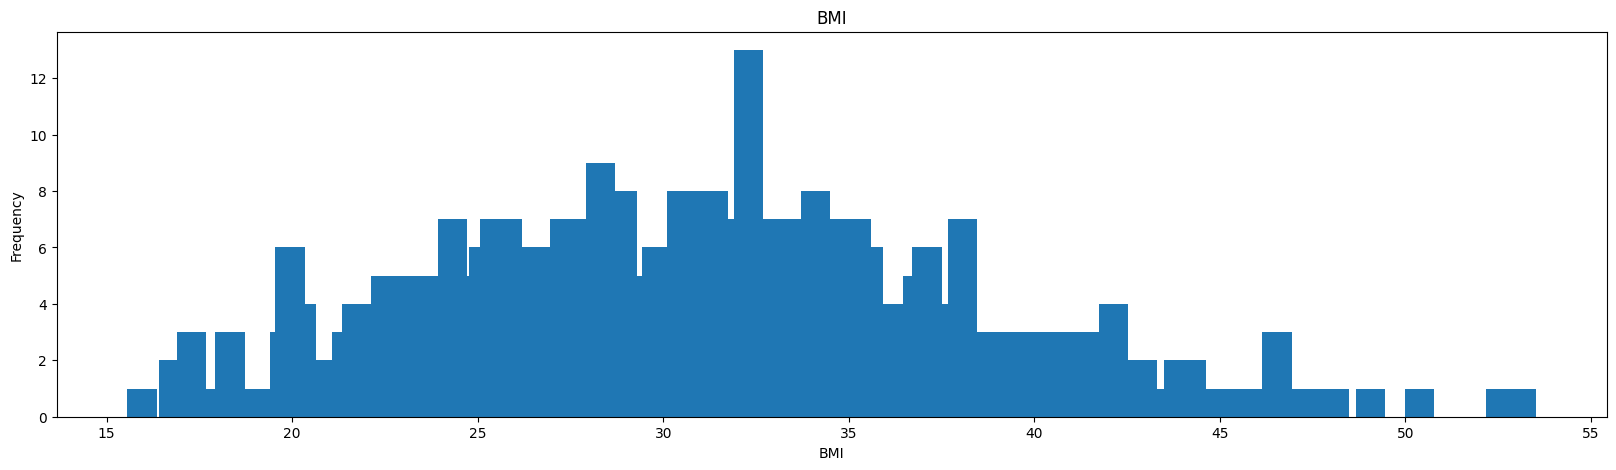

<Figure size 640x480 with 0 Axes>

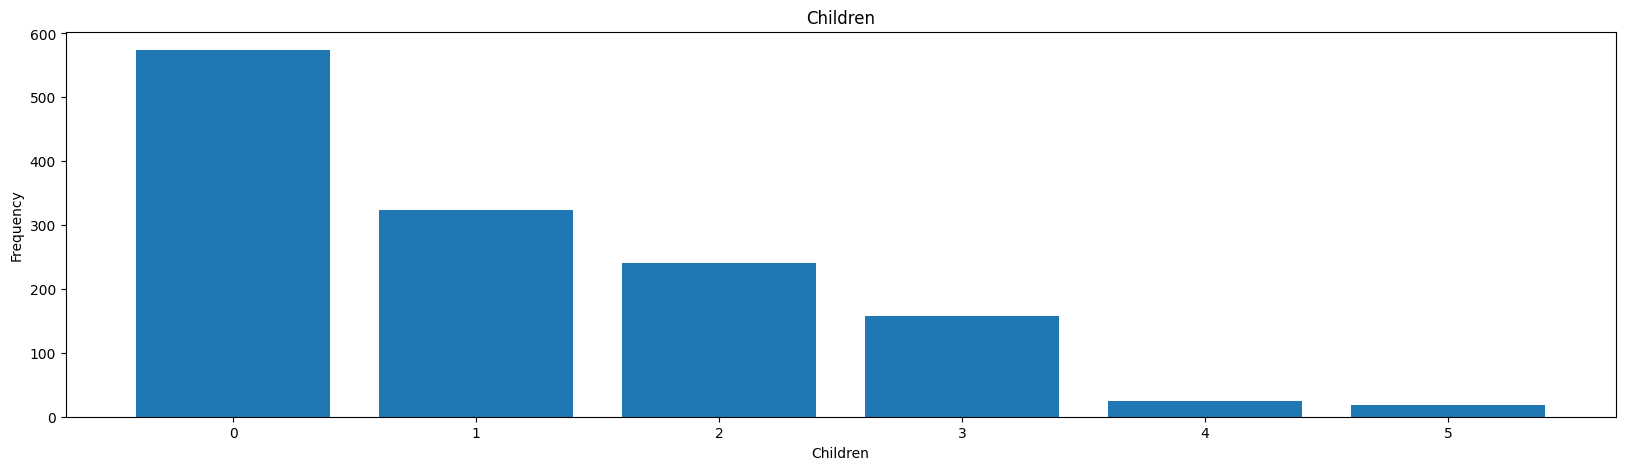

<Figure size 640x480 with 0 Axes>

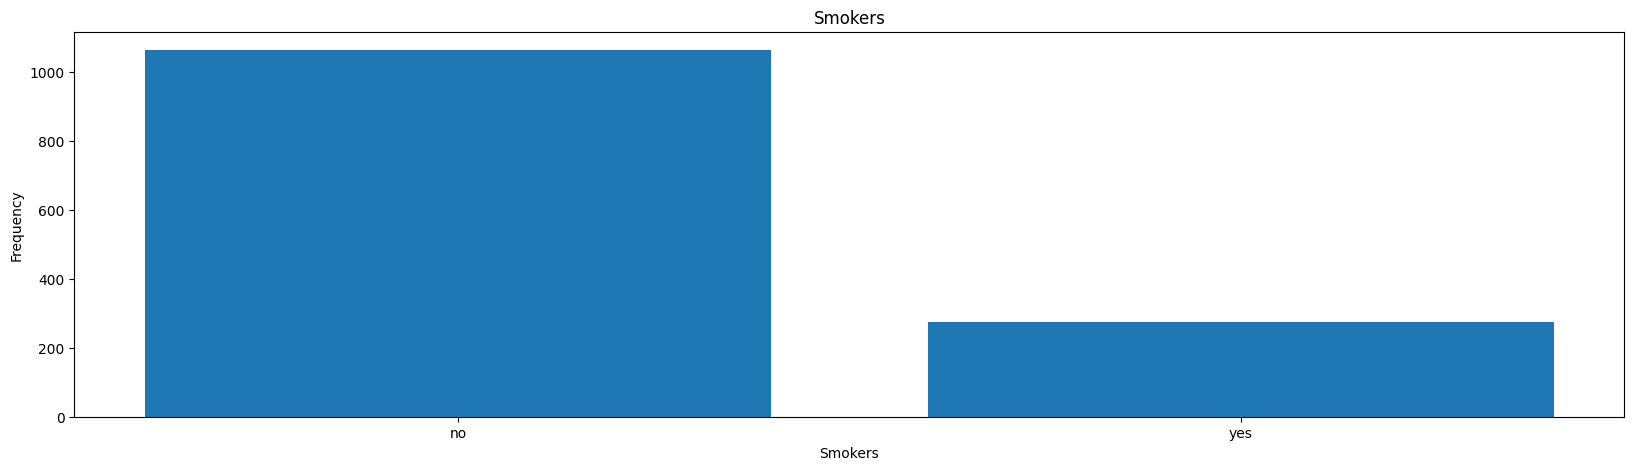

<Figure size 640x480 with 0 Axes>

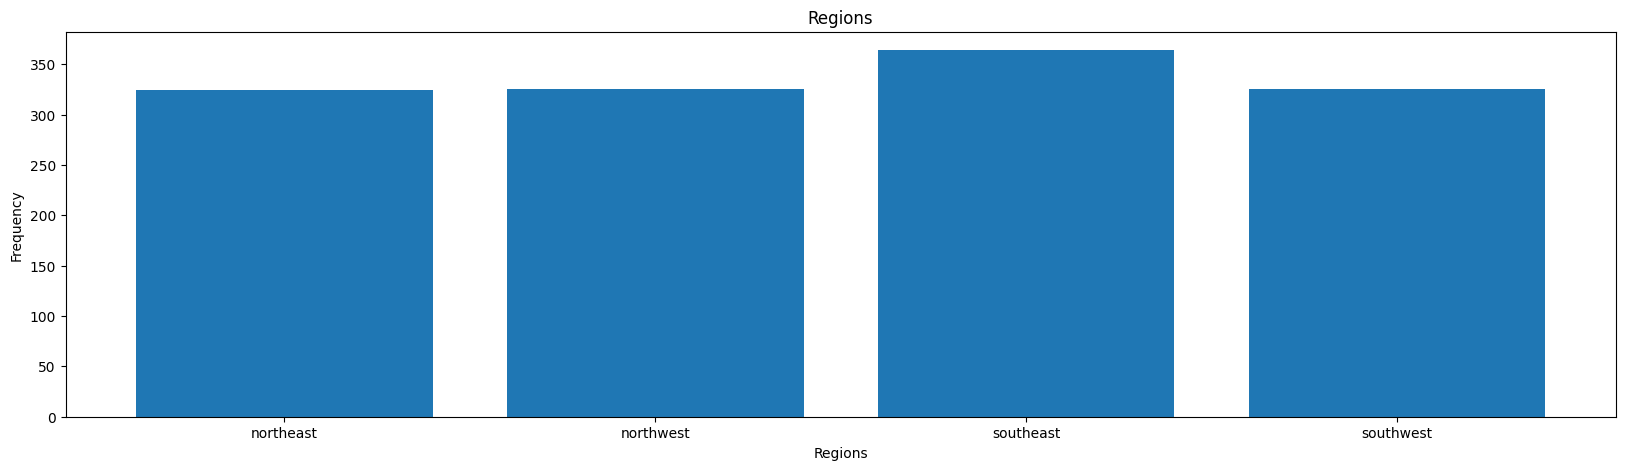

<Figure size 640x480 with 0 Axes>

In [41]:
# Loop generates a bar chart for each of the columns (not including charges)
# The purpose of this procedure is to check that the data does not unduly represent certain populations
# more than others (for instance, having twice as many women as men), although this is not completely avoidable
for i in range(len(sorted_counts)):
    plt.figure(figsize=(20,5))
    plt.bar(sorted_counts[i].keys(), sorted_counts[i].values())
    plt.title(column_variable_names[i])
    plt.xlabel(column_variable_names[i])
    plt.ylabel("Frequency")
    plt.show()
    plt.clf()


# Beginning Exploratory Analysis

In [42]:
## Move this down below
# Looking for correlation between age and charges
# Begin by computing some statistics

# Average charges
average_charges = np.average(charges)
print("Average Charges: " + str(round(average_charges, 2)))

Average Charges: 13270.42


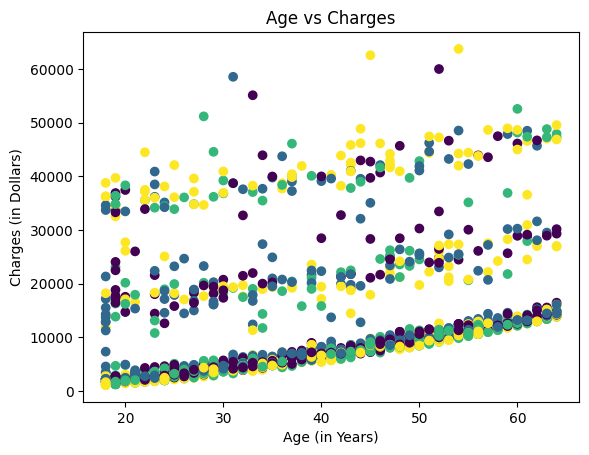

In [43]:
# Scatter plot to plot age versus charges
# Points are colored according region

# Loop through each entry to convert regions to numerals
numerical_region = []
for i in range(len(region)):
    if region[i] == 'northwest':
        numerical_region.append(0)
    elif region[i] == 'northeast':
        numerical_region.append(1)
    elif region[i] == 'southwest':
        numerical_region.append(2)
    else:
        numerical_region.append(3)

# Create scatter plot using matplotlib
plt.scatter(age, charges, c = numerical_region)
plt.title("Age vs Charges")
plt.xlabel("Age (in Years)")
plt.ylabel("Charges (in Dollars)")
plt.show()

Above is a scatter plot that plots age against charges. As can be seen from the graph, charges do seem to increase in a roughly linear fashion as age increases. What's curious is that the data breaks up into three parallel lines of data. The bottom line, which contains individuals having lower charge, is more compact than the other two lines. Attempts were made understand why the data breaks up this way by color coding the points according to the values in the other columns. No pattern was revealed, so more information about these individuals may be needed to clear this up. The scatterplot above color codes the points according to region.

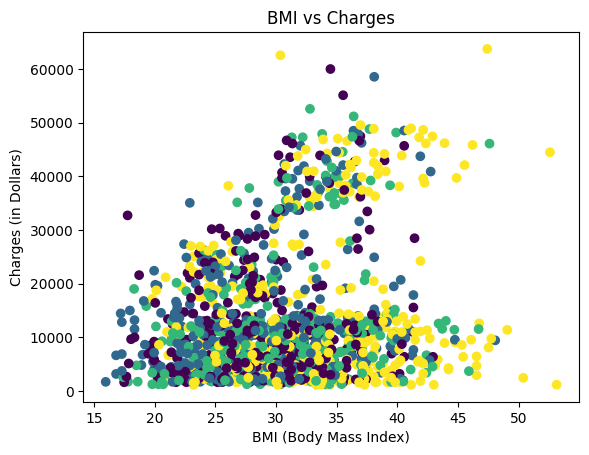

In [44]:
# Scatter plot to plot age versus charges
# Points are colored according region

# Numerical coding of regions borrowed from previous code block
plt.scatter(bmi, charges, c = numerical_region)
plt.title("BMI vs Charges")
plt.xlabel("BMI (Body Mass Index)")
plt.ylabel("Charges (in Dollars)")
plt.show()

Like the previous scatter plot, the points in this scatter plot are color coded according to region, but it is difficult to make out specific patterns. One observation is that as body mass index increases, there does seem to be an increase in the number of data points where the charges are higher, especially for BMI values between about 22 and 40. I am not saying that charges trend upward as BMI increases. There are a lot of data points in that range where the costs are relatively low, but there are also noticeably more points with higher charges in that range than lower BMIs. This does continue when the BMI continues to rise past this range, but it is fair to point out there are far fewer points that exist for BMIs above 40 than in general.

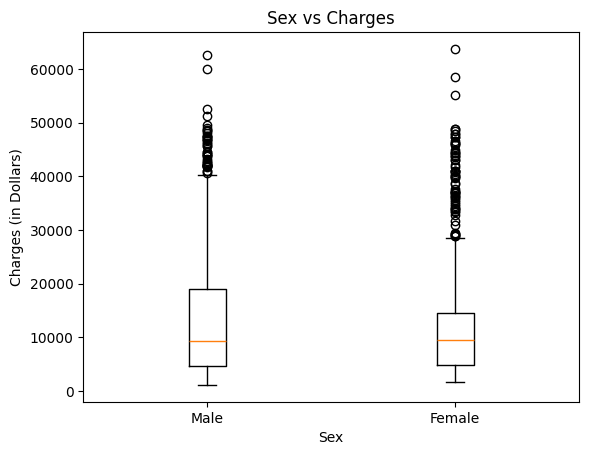

In [45]:
# Sex against charges
male_patients = []
female_patients = []

# Data entries are split between male and female
for entry in insurance_data:
    if entry['sex'] == 'male':
        male_patients.append(entry)
    else:
        female_patients.append(entry)

# List comprehensions of charges for male and female patients
male_charges = [round(float(entry['charges']),2) for entry in male_patients]
female_charges = [round(float(entry['charges']),2) for entry in female_patients]



# Because sex is categorical, box plot is a better choice than scatter plot
plt.boxplot([male_charges, female_charges])
plt.title("Sex vs Charges")
plt.xlabel("Sex")
plt.ylabel("Charges (in Dollars)")
plt.xticks([1,2], ["Male", "Female"])
plt.show()

According to this boxplot, men and women have roughly the same lower end cost and the same median cost, but men have a noticeably larger inner quartile range than women, and there are seemingly a large number of outliers for both groups.

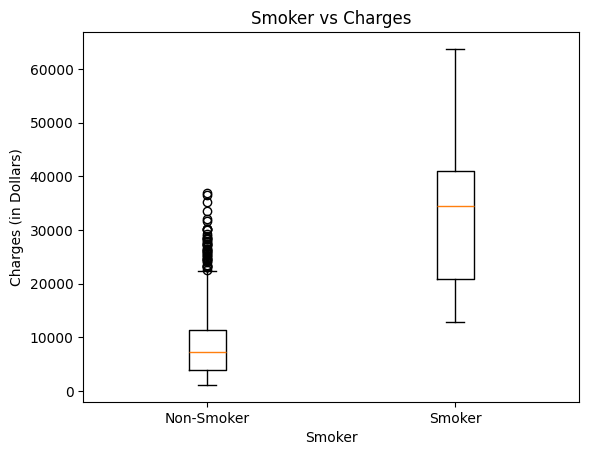

In [46]:
# Smoker against charges
non_smoker_patients = []
smoker_patients = []

# Data entries split between smokers and non-smokers
for entry in insurance_data:
    if entry['smoker'] == 'no':
        non_smoker_patients.append(entry)
    else:
        smoker_patients.append(entry)

# Charges for smokers and non-smokers compiled with list comprehensions
non_smoker_charges = [round(float(entry['charges']),2) for entry in non_smoker_patients]
smoker_charges = [round(float(entry['charges']),2) for entry in smoker_patients]


# Boxplot used because smoker vs non-smoker is categorical
plt.boxplot([non_smoker_charges, smoker_charges])
plt.title("Smoker vs Charges")
plt.xlabel("Smoker")
plt.ylabel("Charges (in Dollars)")
plt.xticks([1,2], ["Non-Smoker", "Smoker"])
plt.show()

Here, the difference between smokers and non-smokers is quite stark. Almost all non-smokers have charges less than 25000 dollars, while the bottom end of the inner quartile range for smokers sits at about 20000 dollars. The median charges for smokers sits at about 35000 dollars, meaning that half of all smokers pay more than that, while only a few outliers in the non-smoker group rise above that threshold. However, it should be noted that according to the Smoker's graph above, there are far fewer smokers than non-smokers (274 compared to 1064).

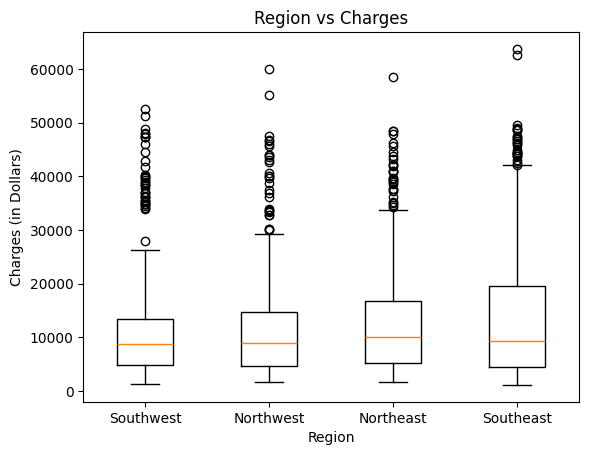

In [47]:
# Region againsts charges
northwest_patients = []
northeast_patients = []
southwest_patients = []
southeast_patients = []

# Data entries split according to regions
for entry in insurance_data:
    if entry['region'] == 'northwest':
        northwest_patients.append(entry)
    elif entry['region'] == 'northeast':
        northeast_patients.append(entry)
    elif entry['region'] == 'southwest':
        southwest_patients.append(entry)
    else:
        southeast_patients.append(entry)
    
# Charges for each entry according to region compiled with list comprehensions
northwest_charges = [round(float(entry['charges']),2) for entry in northwest_patients]
northeast_charges = [round(float(entry['charges']),2) for entry in northeast_patients]
southwest_charges = [round(float(entry['charges']),2) for entry in southwest_patients]
southeast_charges = [round(float(entry['charges']),2) for entry in southeast_patients]


# Regions are categories, so boxplot used
plt.boxplot([southwest_charges, northwest_charges, northeast_charges, southeast_charges])
plt.title("Region vs Charges")
plt.xlabel("Region")
plt.ylabel("Charges (in Dollars)")
plt.xticks([1,2,3,4], ['Southwest', 'Northwest', 'Northeast', 'Southeast'])
plt.show()

Arranged in the order shown, we see that the regions all have similar median charges, but small increases in the size of the inner quartile ranges. The overall ranges also increase from left to right.

# Full Analysis
Based on the exploratory analysis, I have found the boxplots to be more forthcoming with observations that could be turned into a viable project. If I were going to work with the smokers variable, I would prefer that the number of smokers be closer to the number of non-smokers. Also, because the region comparison has more categories, it may be somewhat more challenging to analyze than the sex comparison. As such, my focus from here on out will be on the region comparison.

Questions to Answer:

1. What are the actual interquartile ranges for each region?
2. What is the full data range excluding outliers for each region?
3. What are the mean and median for each region? What is the variance about the mean and median?
4. What are the mean, median and variance of the outliers left to themselves?

Once the appropriate statistics are computed, I will create a dictionary to hold the values. I will also give a brief report of trends in the data.

In [48]:
# Create class for methods
# When inputting values for parameters, remember to input only the charges column from each region
class ChargesByRegion:
    def __init__(self, region_data):
        self.region_data = region_data

    def iqr_range(self, region_data):
        global q1
        q1 = np.quantile(0.25, region_data)
        global q3
        q3 = np.quantile(0.75, region_data)
        iqr = q3 - q1
        return iqr
    
    def tukey_range(self, region_data):
        inter_range = self.iqr_range(region_data)
        whisker = 1.5 * inter_range
        global upper_bound
        upper_bound = q3 + whisker
        global lower_bound
        lower_bound = q1 - whisker
        range_size = upper_bound - lower_bound
        print(f"Upper Bound: {upper_bound}")
        print(f"Lower Bound: {lower_bound}")
        print(f"Whisker to Whisker: {range_size}")

    def mean_med_var(self, region_data):
        region_mean = np.mean(region_data)
        region_median = np.median(region_data)
        mean_variance = np.var(region_data)
        median_variance = np.mean((region_data - region_mean) ** 2) # Got assist from Google AI
        print(f"Average Charges: {region_mean}")
        print(f"Median Charges: {region_median}")
        print(f"Variance About Average: {mean_variance}")
        print(f"Variance About Median: {median_variance}")

    def outlier_stats(self, region_data):
        get_bounds = self.tukey_range(region_data)
        outliers = []
        for entry in region_data:
            if (entry > upper_bound) | (entry < lower_bound):
                outliers.append(entry)
        outlier_mean = np.mean(outliers)
        outlier_median = np.median(outliers)
        outlier_variance = np.var(outliers)
        print(f"Average of Outliers: {outlier_mean}")
        print(f"Median of Outliers: {outlier_median}")
        print(f"Variance of Outliers: {outlier_variance}")

    
# Next step is create dictionary
# Create dictionary outside of class
        

